# Demystifying the Attention Layer in LLMs
### PyAtl Presentation - February 2026

This notebook demonstrates:
1. Tokenization and vectorization
2. Word embeddings and vector arithmetic
3. Attention mechanisms
4. How context modifies meaning

---
## Setup and Installations

In [ ]:
# Install required packages (uncomment if needed)
# !pip install transformers torch numpy matplotlib seaborn gensim bertviz scipy

In [ ]:
import numpy as np
import torch
from transformers import BertTokenizer, BertModel, GPT2Tokenizer, GPT2LMHeadModel
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

---
## Part 1: Tokenization - Breaking Text into Pieces

In [ ]:
# Load a tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

def demonstrate_tokenization(text):
    """Show how text gets broken into tokens"""
    tokens = tokenizer.tokenize(text)
    token_ids = tokenizer.encode(text)
    
    print(f"\nOriginal text: '{text}'")
    print(f"Tokens: {tokens}")
    print(f"Token IDs: {token_ids}")
    print(f"Number of tokens: {len(tokens)}")
    return tokens, token_ids

# NOTE: GPT-2 uses byte-level BPE, which maps all bytes to visible characters.
# The 'Ġ' character (Unicode \u0120) represents a leading space before a token.
# So 'Ġquick' really means ' quick'. The first token in a sequence won't have
# one since there's no preceding space.

In [ ]:
# Pre-loaded examples
example_texts = [
    "Hello, world!",
    "The quick brown fox jumps over the lazy dog.",
    "Tokenization is fascinating!",
    "PyAtl is awesome!"
]

for text in example_texts:
    demonstrate_tokenization(text)

In [ ]:
# The leading space matters! "Python" at the start of a sentence and " Python" after
# a space are different tokens with different IDs in the vocabulary. Capitalization
# also matters as "Python" and "python" are different tokens. Even "PYTHON" is different.
word = "Python"
no_space = tokenizer.encode(word)
with_space = tokenizer.encode(" " + word)
lowercase = tokenizer.encode(word.lower())
uppercase = tokenizer.encode(word.upper())

print(f"'{word}'  -> token IDs: {no_space}  tokens: {tokenizer.tokenize(word)}")
print(f"' {word}' -> token IDs: {with_space}  tokens: {tokenizer.tokenize(' ' + word)}")
print(f"'{word.lower()}' -> token IDs: {lowercase}  tokens: {tokenizer.tokenize(word.lower())}")
print(f"'{word.upper()}' -> token IDs: {uppercase}  tokens: {tokenizer.tokenize(word.upper())}")
print(f"\nSame word, different tokens — position context is baked into the vocabulary.")

In [ ]:
# Try Your Own Text!
demonstrate_tokenization('your text here')

### If capitalization and spacing matter for tokenization and vectorization how can a model ever understand that "Python" and "python" are the same word? Or that "The cat" and "the cat" are the same phrase?

## Using a Different Tokenizer (BERT)

In [ ]:
# Compare with BERT's tokenizer (WordPiece instead of byte-level BPE)
# BERT uses '##' to mark subword continuations (instead of GPT-2's 'Ġ' for spaces)
# and bert-base-uncased lowercases everything — no case duplication.
bert_tok = BertTokenizer.from_pretrained('bert-base-uncased')

def demonstrate_BERT_tokenization(text):
    """Show how BERT tokenizes text"""
    tokens = bert_tok.tokenize(text)
    token_ids = bert_tok.encode(text, add_special_tokens=False)
    
    print(f"\nOriginal text: '{text}'")
    print(f"Tokens: {tokens}")
    print(f"Token IDs: {token_ids}")
    print(f"Number of tokens: {len(tokens)}")
    return tokens, token_ids


print("Same examples with BERT (WordPiece, uncased):\n")
for text in example_texts:
    demonstrate_BERT_tokenization(text)

# Notice:
# - No 'Ġ' characters — spaces are implicit between tokens
# - Everything is lowercased ("The" -> "the")
# - Unknown subwords get '##' prefix (e.g. "PyAtl" -> ["py", "##at", "##l"])
# - BERT also wraps input with special [CLS] and [SEP] tokens (omitted here)

In [ ]:
demonstrate_BERT_tokenization("Python")
demonstrate_BERT_tokenization("python")
demonstrate_BERT_tokenization("PYTHON")
demonstrate_BERT_tokenization(" Python")

---
## Part 2: Word Embeddings - Words as Vectors

In [ ]:
# Load pre-trained word embeddings (using BERT)
# attn_implementation="eager" is needed so output_attentions=True works in Part 3
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased', attn_implementation="eager")
bert_model.eval()

print("BERT model loaded!")

In [ ]:
def get_word_embedding(word):
    """Get the static embedding vector for a single word from BERT's embedding table"""
    token_ids = bert_tokenizer.encode(word, add_special_tokens=False)
    # Use the first token's embedding (handles multi-token words gracefully)
    embedding = bert_model.embeddings.word_embeddings.weight[token_ids[0]]
    return embedding.detach().numpy()

# Pre-compute normalized embedding matrix and token list for fast full-vocab search
_embedding_matrix = bert_model.embeddings.word_embeddings.weight.detach().numpy()
_embedding_norms = np.linalg.norm(_embedding_matrix, axis=1, keepdims=True)
_normalized_embeddings = _embedding_matrix / _embedding_norms

# Build a set of token IDs to skip: subword tokens (##...), special tokens,
# numbers, punctuation, and non-Latin characters
_special_tokens = {'[CLS]', '[SEP]', '[PAD]', '[UNK]', '[MASK]'}
_skip_ids = set()
for _id in range(len(bert_tokenizer)):
    _tok = bert_tokenizer.convert_ids_to_tokens(_id)
    if _tok.startswith('##') or _tok in _special_tokens or not _tok.isascii() or not _tok.isalpha():
        _skip_ids.add(_id)

# Pre-compute the vocabulary-wide mean embedding for centering
_valid_ids = [i for i in range(len(bert_tokenizer)) if i not in _skip_ids]
_vocab_mean = _embedding_matrix[_valid_ids].mean(axis=0)

_whole_word_count = len(bert_tokenizer) - len(_skip_ids)
print(f"Vocab size: {len(bert_tokenizer)} | Searching {_whole_word_count} whole English words")

def _find_nearest(vector, top_n=10, exclude=None):
    """Find the top-N nearest whole words to an arbitrary vector."""
    exclude = {w.lower() for w in (exclude or [])}
    result_norm = vector / np.linalg.norm(vector)
    similarities = _normalized_embeddings @ result_norm
    ranked = np.argsort(similarities)[::-1]
    results = []
    for idx in ranked:
        if int(idx) in _skip_ids:
            continue
        token = bert_tokenizer.convert_ids_to_tokens(int(idx))
        if token in exclude:
            continue
        results.append((token, float(similarities[idx])))
        if len(results) >= top_n:
            break
    return results

def nearest_words(word, top_n=10):
    """Show the nearest neighbors to a word in BERT's embedding space."""
    print(f"\nNearest neighbors to '{word}' (from {_whole_word_count} whole-word tokens):")
    vec = get_word_embedding(word)
    results = _find_nearest(vec, top_n=top_n, exclude={word})
    for i, (token, sim) in enumerate(results, 1):
        print(f"  {i}. {token:15s} (similarity: {sim:.4f})")
    return results

def vector_arithmetic_demo(word1, operation, word2, operation2, word3, top_n=5):
    """
    Demonstrate vector arithmetic: word1 - word2 + word3
    Searches the entire BERT vocabulary (~30K tokens) for nearest neighbors.
    """
    print(f"\nComputing: {word1} {operation} {word2} {operation2} {word3}")
    
    v1 = get_word_embedding(word1)
    v2 = get_word_embedding(word2)
    v3 = get_word_embedding(word3)
    
    if operation == '-' and operation2 == '+':
        result_vector = v1 - v2 + v3
    else:
        print("Currently only supports 'word1 - word2 + word3' format")
        return
    
    results = _find_nearest(result_vector, top_n=top_n, exclude={word1, word2, word3})
    
    print(f"\nTop {top_n} most similar words (from {_whole_word_count} whole-word tokens):")
    for i, (word, sim) in enumerate(results, 1):
        print(f"  {i}. {word:15s} (similarity: {sim:.4f})")
    
    return results

def explore_axis(dim, top_n=10):
    """
    Show words at the extremes of a single embedding dimension.
    Helps reveal what a particular axis in the vector space might encode.
    """
    ndim = _embedding_matrix.shape[1]
    if not 0 <= dim < ndim:
        print(f"Dimension must be between 0 and {ndim - 1}")
        return
    
    axis_values = _embedding_matrix[:, dim]
    ranked = np.argsort(axis_values)
    
    # Collect top/bottom words, skipping filtered tokens
    high_words, low_words = [], []
    for idx in reversed(ranked):
        if int(idx) in _skip_ids:
            continue
        token = bert_tokenizer.convert_ids_to_tokens(int(idx))
        high_words.append((token, float(axis_values[idx])))
        if len(high_words) >= top_n:
            break
    for idx in ranked:
        if int(idx) in _skip_ids:
            continue
        token = bert_tokenizer.convert_ids_to_tokens(int(idx))
        low_words.append((token, float(axis_values[idx])))
        if len(low_words) >= top_n:
            break
    
    print(f"\n--- Dimension {dim} ---")
    print(f"\n  HIGH end (positive):")
    for i, (word, val) in enumerate(high_words, 1):
        print(f"    {i}. {word:15s} ({val:+.4f})")
    print(f"\n  LOW end (negative):")
    for i, (word, val) in enumerate(low_words, 1):
        print(f"    {i}. {word:15s} ({val:+.4f})")
    
    return high_words, low_words

def shared_direction(words, top_n=10):
    """
    Given a list of words, find the concept direction they share.
    Computes a centroid, subtracts the vocab-wide mean to isolate what
    makes this group *distinctive*, then finds nearest/farthest words.
    Also reports which embedding dimensions contribute most to the direction.
    """
    embeddings = np.array([get_word_embedding(w) for w in words])
    centroid = embeddings.mean(axis=0)
    
    # Subtract vocab mean to get the *distinctive* direction
    direction = centroid - _vocab_mean
    
    print(f"\nShared direction for: {words}")
    print(f"\n  Closest words (share this quality):")
    close = _find_nearest(direction, top_n=top_n, exclude=set(words))
    for i, (token, sim) in enumerate(close, 1):
        print(f"    {i}. {token:15s} (similarity: {sim:.4f})")
    
    print(f"\n  Farthest words (opposite end):")
    far = _find_nearest(-direction, top_n=top_n, exclude=set(words))
    for i, (token, sim) in enumerate(far, 1):
        print(f"    {i}. {token:15s} (similarity: {sim:.4f})")
    
    # Report the top dimensions that define this direction
    top_dims = np.argsort(np.abs(direction))[::-1][:5]
    print(f"\n  Top 5 dimensions defining this direction:")
    for dim in top_dims:
        sign = "+" if direction[dim] > 0 else "-"
        print(f"    dim {dim:3d}  ({sign}{abs(direction[dim]):.4f})")
    
    return direction, close, far

In [ ]:
# What does a word embedding actually look like?
def embedding_preview_summary(word):
    vec = get_word_embedding(word)
    n = 4  # how many values to show from each end

    print(f"Embedding for '{word}':  ({len(vec)})")
    head = ', '.join(f'{v:+.4f}' for v in vec[:n])
    tail = ', '.join(f'{v:+.4f}' for v in vec[-n:])
    print(f"  [{head},  ...  {tail}]")
    #print(f"\n  min: {vec.min():.4f}   max: {vec.max():.4f}   mean: {vec.mean():.4f}")

## What words live near "python" in embedding space?

In [ ]:
word = "python"
_ = embedding_preview_summary(word)
_ = nearest_words(word)

## What do reptiles have in common? Find the "reptile-ness" direction.

In [ ]:
reptile_direction, close, far = shared_direction(
    ['snake', 'lizard', 'turtle', 'crocodile', 'alligator']
)

## Now explore the strongest dimension from the "reptile-ness" direction.
## Does it look reptile-y, or is it encoding something more general?

In [ ]:

top_reptile_dim = int(np.argsort(np.abs(reptile_direction))[::-1][0])
print(f"The strongest 'reptile-ness' dimension is {top_reptile_dim} — let's see what lives there:\n")
_ = explore_axis(top_reptile_dim)

## Okay, if tokens are just vectors and different axes encode different concepts... what happens if I perform arithmetic on those vectors?

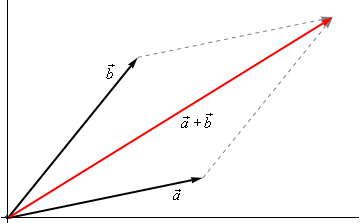
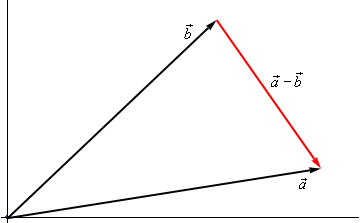

In [ ]:
# Classic Example: Gender Analogy
_ = vector_arithmetic_demo('king', '-', 'man', '+', 'woman')

In [ ]:
# Historical Leaders Example
_ = vector_arithmetic_demo('hitler', '-', 'germany', '+', 'italy')

In [ ]:
# National Capitals Example
_ = vector_arithmetic_demo('paris', '-', 'france', '+', 'japan')

In [ ]:
# Try your own!
a = "best"
b = "good"
c = "bad"
_ =vector_arithmetic_demo(a, '-', b, '+', c)

---
## Part 3: Attention Mechanism - The Magic Happens Here

In [141]:
def visualize_attention(text, layer=0, head=0):
    """
    Visualize attention weights for a given text.
    Shows which words the model pays attention to.
    """
    inputs = bert_tokenizer(text, return_tensors='pt')
    
    with torch.no_grad():
        outputs = bert_model(**inputs, output_attentions=True)
    
    attention = outputs.attentions[layer][0, head].numpy()
    tokens = bert_tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(attention, 
                xticklabels=tokens, 
                yticklabels=tokens,
                cmap='YlOrRd',
                cbar_kws={'label': 'Attention Weight'})
    plt.title(f'Attention Weights - Layer {layer}, Head {head}\n"{text}"')
    plt.xlabel('Key (attending to)')
    plt.ylabel('Query (attending from)')
    plt.tight_layout()
    plt.show()
    
    return attention, tokens

- BERT has 12 layers and 12 heads per layer.
- Each "Head" operates in the same embedding space but learns to focus on different relationships (projections).
- BERT has a 768-dimensional embedding space, but each head only attends to a single aspect of it (64 dimensions).
- The 12 heads are then recombined (12 x 64 = 768) and passed to the next layer, which learns new projections on top of that.
- Early layers tend to show simpler patterns with each head tending do different aspects (Adjacent words, punctuation, syntax, coreference, etc.)

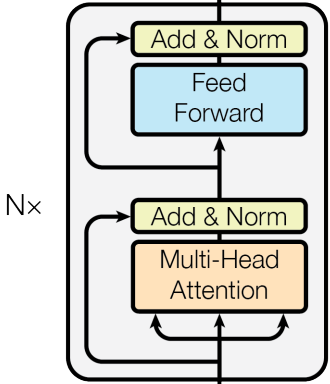


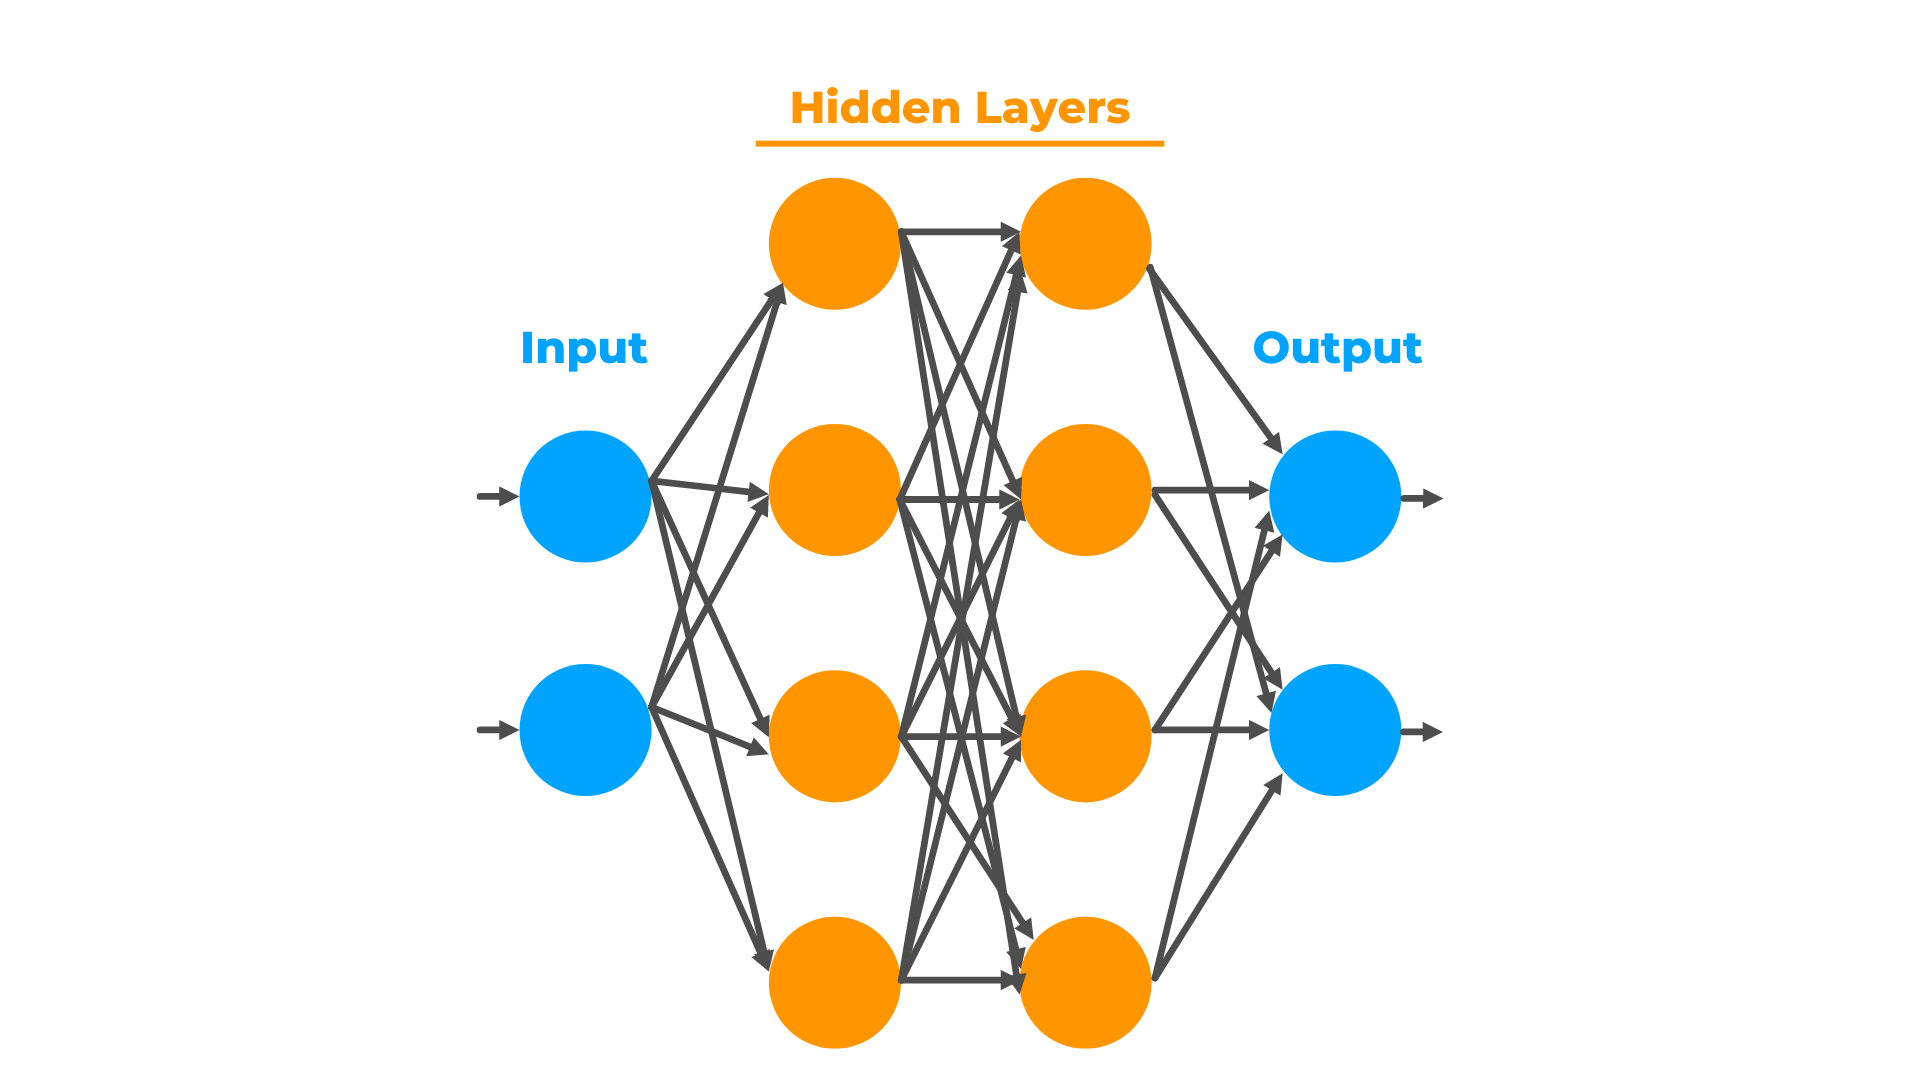

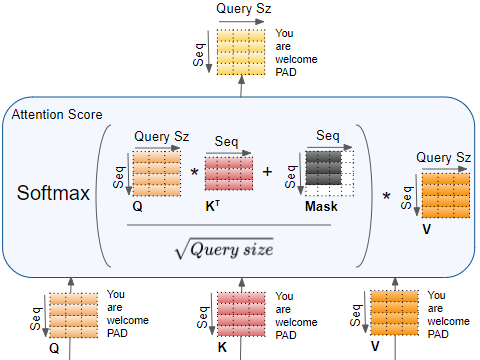

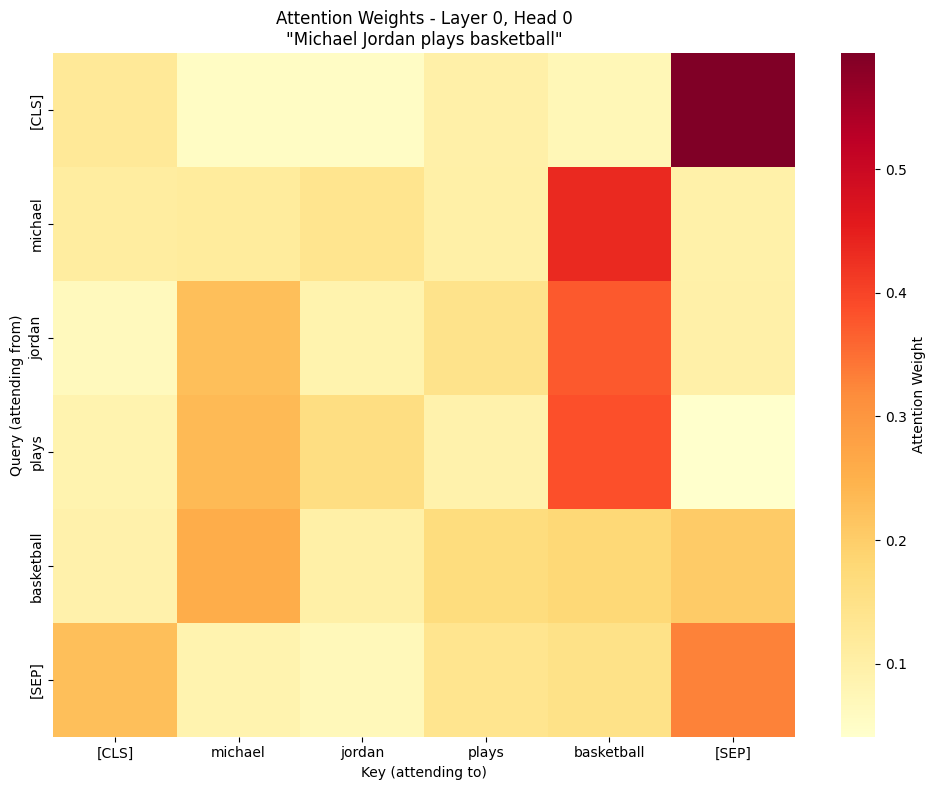

In [142]:

_ = visualize_attention("Michael Jordan plays basketball", layer=0, head=0) #0, 2, 5, 

### To understand what 'michael' (Query) means in this sentence, the model looks at 'basketball' (Key) this much.  
### How much WEIGHT does each word give to every other word?


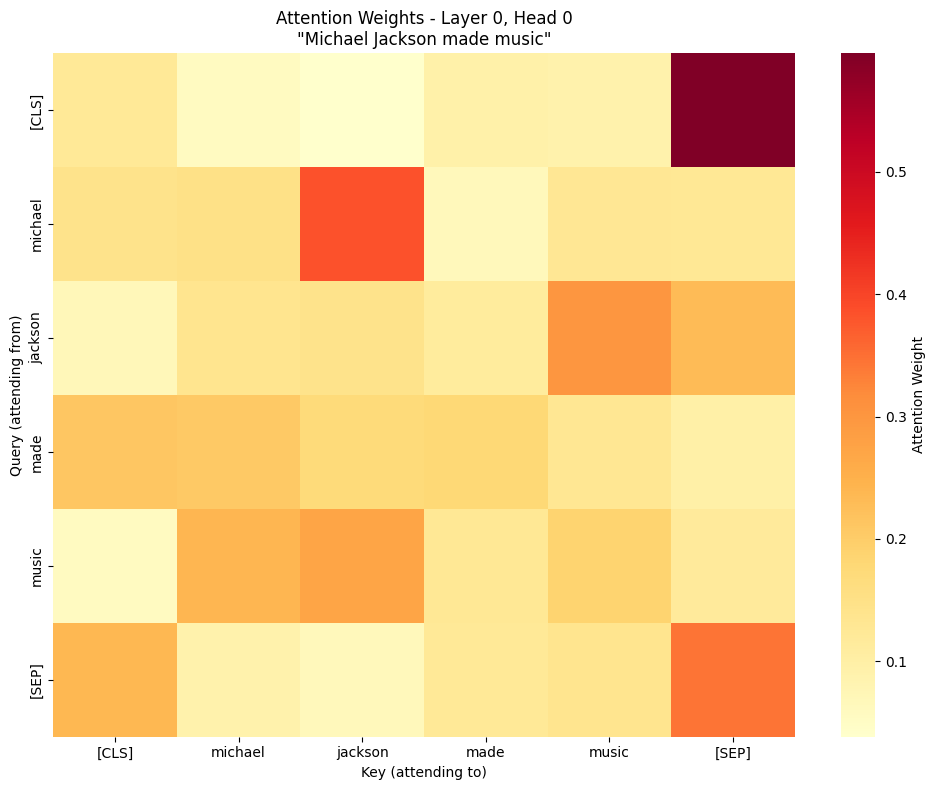

In [143]:
_ = visualize_attention("Michael Jackson made music", layer=0, head=0)

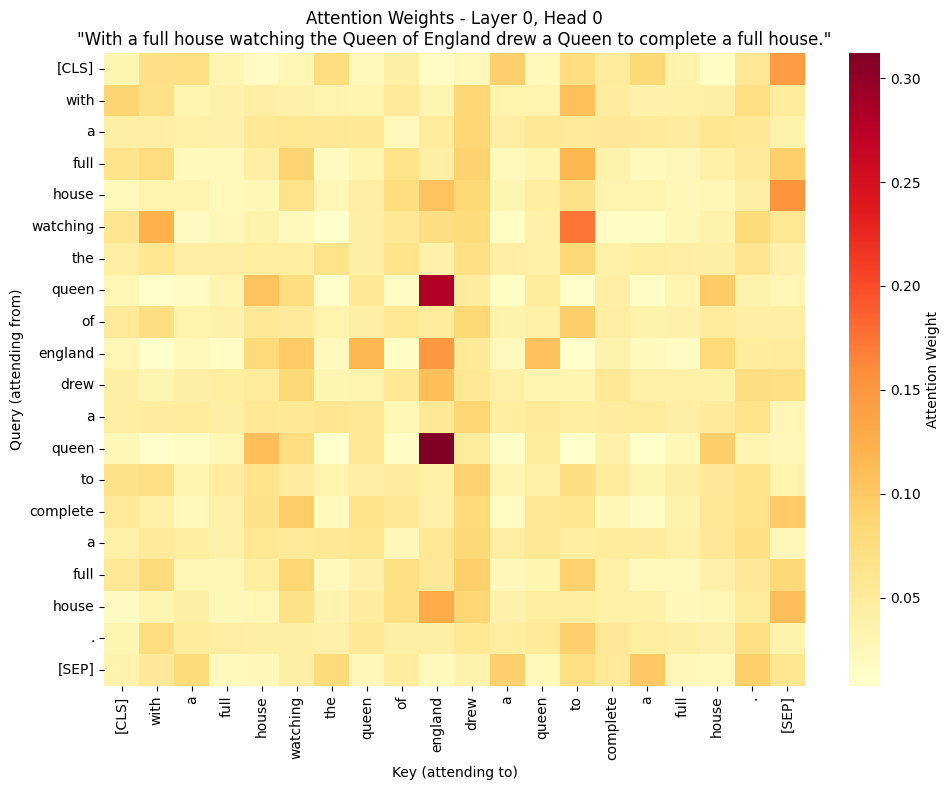

In [144]:
_ =visualize_attention("With a full house watching the Queen of England drew a Queen to complete a full house.", layer=0, head=0)

---
## Part 4: Contextual Embeddings - Same Word, Different Meanings

In [ ]:
from transformers import BertForMaskedLM

# Load the MLM variant of BERT — it has a trained projection from contextual
# embeddings back to vocabulary, which is exactly what we need to ask
# "what word does this position now represent?"
_mlm_model = BertForMaskedLM.from_pretrained('bert-base-uncased', attn_implementation="eager")
_mlm_model.eval()

_GREEN = '\033[32m'
_RESET = '\033[0m'

def compare_contextualized_embeddings(word, sentence1, sentence2, probe_words=None, top_n=5):
    """
    Show how the same word gets different embeddings in different contexts.
    
    probe_words: optional list of concept words to compare against.
        Shows how attention "adds" or "subtracts" these concepts from the
        word's vector — analogous to the vector arithmetic in Part 2,
        but done automatically by the attention mechanism.
    """
    print(f"\nAnalyzing the word '{word}' in different contexts:")
    print(f"  Context 1: '{sentence1}'")
    print(f"  Context 2: '{sentence2}'")
    
    def get_contextual_embedding(word, sentence):
        inputs = bert_tokenizer(sentence, return_tensors='pt')
        with torch.no_grad():
            outputs = bert_model(**inputs)
        tokens = bert_tokenizer.tokenize(sentence)
        for i, token in enumerate(tokens):
            if word.lower() in token.lower():
                embedding = outputs.last_hidden_state[0, i+1, :].numpy()
                return embedding
        return None
    
    def get_mlm_predictions(word, sentence, top_n):
        """Mask the word, then ask BERT what it thinks belongs there."""
        masked_sentence = sentence.lower().replace(word.lower(), '[MASK]', 1)
        inputs = bert_tokenizer(masked_sentence, return_tensors='pt')
        
        mask_token_id = bert_tokenizer.convert_tokens_to_ids('[MASK]')
        mask_pos = (inputs['input_ids'][0] == mask_token_id).nonzero(as_tuple=True)[0].item()
        
        with torch.no_grad():
            logits = _mlm_model(**inputs).logits
        probs = torch.softmax(logits[0, mask_pos, :], dim=0).numpy()
        ranked = np.argsort(probs)[::-1]
        
        results = []
        for idx in ranked:
            if int(idx) in _skip_ids:
                continue
            token = bert_tokenizer.convert_ids_to_tokens(int(idx))
            results.append((token, float(probs[idx])))
            if len(results) >= top_n:
                break
        return results
    
    emb1 = get_contextual_embedding(word, sentence1)
    emb2 = get_contextual_embedding(word, sentence2)
    
    if emb1 is not None and emb2 is not None:
        similarity = 1 - cosine(emb1, emb2)
        print(f"\n  Cosine similarity between the two '{word}' embeddings: {similarity:.4f}")
        print(f"     (1.0 = identical, 0.0 = completely different)")
        
        if similarity > 0.9:
            print("     -> Very similar meanings in both contexts")
        elif similarity > 0.7:
            print("     -> Somewhat similar meanings")
        else:
            print("     -> Quite different meanings! Attention modified the representation.")
        
        # Probe word comparison — show how attention shifted the vector
        if probe_words:
            print(f"\n  How does '{word}' relate to these concepts in each context?")
            print(f"     {'concept':<15s} {'context 1':>10s} {'context 2':>10s}")
            print(f"     {'-------':<15s} {'---------':>10s} {'---------':>10s}")
            for probe in probe_words:
                probe_vec = get_word_embedding(probe)
                sim_ctx1 = 1 - cosine(emb1, probe_vec)
                sim_ctx2 = 1 - cosine(emb2, probe_vec)
                val1 = f"{sim_ctx1:>10.4f}"
                val2 = f"{sim_ctx2:>10.4f}"
                if sim_ctx1 > sim_ctx2:
                    val1 = f"{_GREEN}{val1}{_RESET}"
                elif sim_ctx2 > sim_ctx1:
                    val2 = f"{_GREEN}{val2}{_RESET}"
                print(f"     {probe:<15s} {val1} {val2}")
        
        # Mask the word and show what BERT predicts for each context
        print(f"\n  If we mask '{word}' in context 1, BERT predicts:")
        for i, (token, prob) in enumerate(get_mlm_predictions(word, sentence1, top_n), 1):
            print(f"    {i}. {token:15s} ({prob:.2%})")
        
        print(f"\n  If we mask '{word}' in context 2, BERT predicts:")
        for i, (token, prob) in enumerate(get_mlm_predictions(word, sentence2, top_n), 1):
            print(f"    {i}. {token:15s} ({prob:.2%})")
    
    return emb1, emb2, similarity

In [ ]:
# Polysemous Word 'Bank'
_ = compare_contextualized_embeddings(
    'bank',
    'I deposited money at the bank.',
    'We sat on the river bank.',
    probe_words=['money', 'finance', 'river', 'water']
)

In [ ]:
# Python
_ = compare_contextualized_embeddings(
    'python',
    'I love programming in Python, it is such a versatile language.',
    'The python slithered through the jungle looking to find a meal.',
    probe_words=['java', 'snake', 'code', 'jungle', 'language', 'reptile']
)

In [ ]:
# Word 'bat'
_ = compare_contextualized_embeddings(
    'bat',
    'He swung the bat and hit a home run.',
    'The bat flew out of the dark cave.',
    probe_words=['baseball', 'wings', 'sport', 'animal', 'ball', 'cave']
)

In [ ]:
# Try your own!
_ = compare_contextualized_embeddings(
    'word', 
    'Sentence with word 1.', 
    'Sentence with word 2.',
    probe_words=['concept1', 'concept2', 'concept3'])

---
## Part 5: Next Token Prediction - It's More Than It Seems!

In [ ]:
# Load GPT-2 for generation
gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_model = GPT2LMHeadModel.from_pretrained('gpt2')
gpt2_model.eval()

print("GPT-2 model loaded!")

In [ ]:
def predict_next_tokens(prompt, top_k=10):
    """
    Show the top-k most likely next tokens.
    This demonstrates that 'predicting the next word' requires
    understanding context, syntax, semantics, and reasoning.
    """
    print(f"\nPredicting next token after: '{prompt}'")
    
    inputs = gpt2_tokenizer.encode(prompt, return_tensors='pt')
    
    with torch.no_grad():
        outputs = gpt2_model(inputs)
        predictions = outputs.logits
    
    next_token_logits = predictions[0, -1, :]
    next_token_probs = torch.softmax(next_token_logits, dim=0)
    
    top_probs, top_indices = torch.topk(next_token_probs, top_k)
    
    print(f"\nTop {top_k} most likely next tokens:")
    for i, (prob, idx) in enumerate(zip(top_probs, top_indices), 1):
        token = gpt2_tokenizer.decode([idx])
        print(f"  {i}. '{token}' (probability: {prob:.4f})")
    
    return top_probs, top_indices

In [ ]:
# Simple Completion
predict_next_tokens("In 1969, humans first landed on the")

In [ ]:
# Context-Dependent
predict_next_tokens("After winning the NBA championship, Michael")

In [ ]:
# Requires World Knowledge
predict_next_tokens("Python is a programming")

In [ ]:
# Try your own!
predict_next_tokens('your prompt here')

### What happens if we remove attention entirely?
Same model, same weights, same embeddings — but we skip all 12 transformer layers. Without attention, the model can only see each token's static embedding and position. No context, no understanding.

In [ ]:
def predict_with_without_attention(prompt, top_k=5):
    """Compare next-token predictions with and without attention layers."""
    input_ids = gpt2_tokenizer.encode(prompt, return_tensors='pt')
    
    # WITH attention — normal forward pass through all 12 transformer layers
    with torch.no_grad():
        full_logits = gpt2_model(input_ids).logits
    full_probs = torch.softmax(full_logits[0, -1, :], dim=0)
    
    # WITHOUT attention — skip all transformer layers, use only embeddings
    with torch.no_grad():
        token_embs = gpt2_model.transformer.wte(input_ids)
        pos_ids = torch.arange(input_ids.shape[1]).unsqueeze(0)
        pos_embs = gpt2_model.transformer.wpe(pos_ids)
        hidden = token_embs + pos_embs
        hidden = gpt2_model.transformer.ln_f(hidden)
        no_attn_logits = gpt2_model.lm_head(hidden)
    no_attn_probs = torch.softmax(no_attn_logits[0, -1, :], dim=0)
    
    print(f"\nPrompt: '{prompt}'")
    
    print(f"\n  {_GREEN}WITH attention (full model):{_RESET}")
    top_probs, top_indices = torch.topk(full_probs, top_k)
    for i, (prob, idx) in enumerate(zip(top_probs, top_indices), 1):
        token = gpt2_tokenizer.decode([idx])
        print(f"    {i}. '{token}' ({prob:.2%})")
    
    print(f"\n  WITHOUT attention (embeddings only):")
    top_probs, top_indices = torch.topk(no_attn_probs, top_k)
    for i, (prob, idx) in enumerate(zip(top_probs, top_indices), 1):
        token = gpt2_tokenizer.decode([idx])
        print(f"    {i}. '{token}' ({prob:.2%})")

In [ ]:
_ = predict_with_without_attention("In 1969, humans first landed on the")
_ = predict_with_without_attention("After winning the NBA championship, Michael")
_ = predict_with_without_attention("Python is a programming")

---
## Key Takeaways

1. **TOKENIZATION**: Text is broken into tokens (subwords) for processing

2. **EMBEDDINGS**: Words are represented as vectors in high-dimensional space
   - Similar concepts are closer together
   - Vector arithmetic captures semantic relationships

3. **ATTENTION**: The mechanism that allows context to modify meaning
   - Same word, different contexts -> different internal representations
   - The model learns which words to pay attention to

4. **LAYERS**: Deeper layers capture more abstract/complex patterns
   - Early layers: syntax and simple patterns
   - Later layers: reasoning, world knowledge, complex relationships

5. **"JUST PREDICTING THE NEXT WORD"**:
   Yes, but to do so accurately requires:
   - Understanding grammar and syntax
   - Modeling semantic relationships
   - Incorporating world knowledge
   - Reasoning about context
   
   Saying an LLM "just predicts the next word" is like saying a 
   chess grandmaster "just moves pieces" - technically true but 
   misses the sophisticated internal modeling that makes it possible!

---

**Thanks for exploring LLMs with me! Questions?**